# 02 — Vocabulario y Tokenización

**Proyecto:** D10Sformer — MIA305 (UdeSA, 2026)
**Fase:** 2 — Vocabulario futbolístico y tokenizer

## Objetivo

Construir el **vocabulario del lenguaje futbolístico** que va a procesar el Transformer, y demostrar que el tokenizer convierte correctamente:

- **Partidos ricos** (StatsBomb) → secuencia completa con alineaciones + eventos
- **Partidos sparse** (solo resultado) → secuencia mínima usable
- **Partidos con info parcial** (lineups confirmados pero sin eventos) → mix
- **Partidos con masking forzado** (predicción 3 semanas antes) → usar `[MASK]` para campos no disponibles

## Decisiones de diseño confirmadas

1. Buckets de minutos: **15 min** (`MIN_0_15`, `MIN_16_30`, ...)
2. Threshold para token dedicado de jugador: **k=10** partidos
3. Estrategia para alineación desconocida: **`[MASK]`** (consistente con MLM)

## Implementación

Todo el código está en módulos reusables:
- `src/data/vocabulary.py` — clase `FootballVocab`, bucketización, fallback jerárquico
- `src/data/tokenizer.py` — clase `MatchTokenizer`, schema del documento

46 tests unitarios validan la lógica antes de aplicarla a datos reales.

---
## 1. Setup

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/d10sformer'
except ImportError:
    import os
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

import sys
sys.path.insert(0, f'{PROJECT_ROOT}/src')
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/d10sformer


In [2]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)

from data.vocabulary import FootballVocab
from data.tokenizer import (
    MatchTokenizer, MatchDocument, PlayerRef, MatchEvent, RollingFeatures,
)

DATA_RAW = Path(PROJECT_ROOT) / 'data' / 'raw'
DATA_INTERIM = Path(PROJECT_ROOT) / 'data' / 'interim'
DATA_PROCESSED = Path(PROJECT_ROOT) / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
STATSBOMB_PATH = DATA_RAW / 'statsbomb' / 'data'

print('✓ Imports OK')

✓ Imports OK


---
## 2. Recolectar entidades de StatsBomb

Necesitamos enumerar todos los `teams`, `tournaments`, y `players` (con sus posiciones y conteo de apariciones).

In [3]:
# Cargar todos los partidos de StatsBomb
all_sb_matches = []
matches_root = STATSBOMB_PATH / 'matches'
for comp_dir in matches_root.iterdir():
    for season_file in comp_dir.glob('*.json'):
        matches = json.loads(season_file.read_text())
        for m in matches:
            m['_comp_id'] = comp_dir.name
            m['_season_id'] = season_file.stem
            all_sb_matches.append(m)

print(f'Partidos en StatsBomb: {len(all_sb_matches):,}')

# Entidades
sb_teams = set()
sb_tournaments = set()
for m in all_sb_matches:
    sb_teams.add(m['home_team']['home_team_name'])
    sb_teams.add(m['away_team']['away_team_name'])
    sb_tournaments.add(m['competition']['competition_name'])

print(f'Equipos únicos en StatsBomb: {len(sb_teams)}')
print(f'Torneos únicos en StatsBomb: {len(sb_tournaments)}')

Partidos en StatsBomb: 3,464
Equipos únicos en StatsBomb: 308
Torneos únicos en StatsBomb: 21


---
## 3. Cargar lineups: jugadores, apariciones, posiciones

Para cada jugador queremos:
- Número total de partidos donde aparece (define si recibe token dedicado o fallback)
- Posición más frecuente (define el fallback)

In [4]:
def map_statsbomb_position(sb_pos: str) -> str:
    """Mapea la nomenclatura de StatsBomb a {GK, DF, MF, FW}."""
    p = (sb_pos or '').lower()
    if 'goalkeeper' in p:
        return 'GK'
    if 'back' in p or 'defender' in p or 'defense' in p:
        return 'DF'
    if 'midfield' in p:
        return 'MF'
    if 'forward' in p or 'striker' in p or 'wing' in p:
        return 'FW'
    return 'UNKNOWN'

player_appearances = Counter()
player_position_counts = defaultdict(Counter)
player_names = {}

missing_lineups = 0
for m in tqdm(all_sb_matches, desc='Loading lineups'):
    lineup_path = STATSBOMB_PATH / 'lineups' / f'{m["match_id"]}.json'
    if not lineup_path.exists():
        missing_lineups += 1
        continue
    try:
        lineup = json.loads(lineup_path.read_text())
    except Exception:
        missing_lineups += 1
        continue
    for team_lineup in lineup:
        for player in team_lineup.get('lineup', []):
            pid = str(player['player_id'])
            player_appearances[pid] += 1
            player_names[pid] = player['player_name']
            # StatsBomb v3+ tiene 'positions' como lista; v2 puede tener 'position_id'
            for pos_entry in player.get('positions', []):
                pos_name = pos_entry.get('position', '')
                player_position_counts[pid][map_statsbomb_position(pos_name)] += 1

# Posición final = la más común vista
player_positions_final = {
    pid: (cnts.most_common(1)[0][0] if cnts else 'UNKNOWN')
    for pid, cnts in player_position_counts.items()
}
# Default UNKNOWN para jugadores sin info de posiciones
for pid in player_appearances:
    if pid not in player_positions_final:
        player_positions_final[pid] = 'UNKNOWN'

print(f'\nLineups missing: {missing_lineups} / {len(all_sb_matches)}')
print(f'Jugadores únicos: {len(player_appearances):,}')
print(f'Apariciones totales: {sum(player_appearances.values()):,}')
print(f'\nDistribución de apariciones:')
appearances_series = pd.Series(player_appearances)
print(appearances_series.describe().round(1))

Loading lineups: 100%|██████████| 3464/3464 [51:32<00:00,  1.12it/s]


Lineups missing: 0 / 3464
Jugadores únicos: 10,803
Apariciones totales: 131,901

Distribución de apariciones:
count    10803.0
mean        12.2
std         18.6
min          1.0
25%          2.0
50%          4.0
75%         17.0
max        604.0
dtype: float64


Threshold k=10:
  Jugadores con token dedicado (>= 10 partidos): 3,600
  Jugadores que caen en fallback (< 10 partidos): 7,203
  % con token dedicado: 33.3%


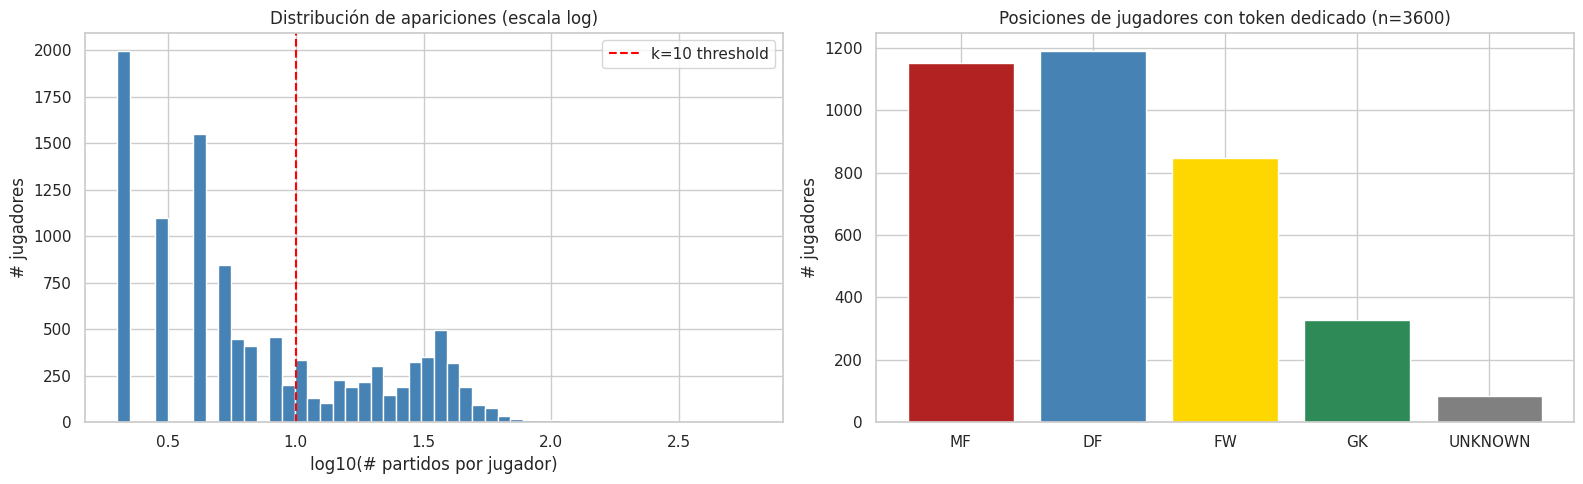


Distribución de posiciones (jugadores dedicated): {'MF': 1152, 'DF': 1189, 'FW': 846, 'GK': 329, 'UNKNOWN': 84}


In [5]:
# Distribución de la cola larga
K = 10  # threshold
n_dedicated = (appearances_series >= K).sum()
n_fallback = (appearances_series < K).sum()
print(f'Threshold k={K}:')
print(f'  Jugadores con token dedicado (>= {K} partidos): {n_dedicated:,}')
print(f'  Jugadores que caen en fallback (< {K} partidos): {n_fallback:,}')
print(f'  % con token dedicado: {n_dedicated / len(appearances_series) * 100:.1f}%')

# Histograma log-log
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(np.log10(appearances_series + 1), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(np.log10(K), color='red', linestyle='--', label=f'k={K} threshold')
axes[0].set_xlabel('log10(# partidos por jugador)')
axes[0].set_ylabel('# jugadores')
axes[0].set_title('Distribución de apariciones (escala log)')
axes[0].legend()

# Distribución de posiciones (entre jugadores dedicated)
dedicated_pids = appearances_series[appearances_series >= K].index
pos_dist = Counter(player_positions_final[p] for p in dedicated_pids)
axes[1].bar(pos_dist.keys(), pos_dist.values(), color=['firebrick', 'steelblue', 'gold', 'seagreen', 'gray'])
axes[1].set_title(f'Posiciones de jugadores con token dedicado (n={n_dedicated})')
axes[1].set_ylabel('# jugadores')
plt.tight_layout(); plt.show()

print(f'\nDistribución de posiciones (jugadores dedicated): {dict(pos_dist)}')

---
## 4. Sumar entidades del dataset internacional (martj42)

Más equipos y torneos que no están en StatsBomb (selecciones de África, Asia, Oceanía menos cubiertas).

In [6]:
df_int = pd.read_parquet(DATA_INTERIM / 'international_matches_with_elo.parquet')
df_int['date'] = pd.to_datetime(df_int['date'])

int_teams = set(df_int.home_team) | set(df_int.away_team)
int_tournaments = set(df_int.tournament)

print(f'Equipos en martj42: {len(int_teams)}')
print(f'Torneos en martj42: {len(int_tournaments)}')

# Unión total
all_teams = sb_teams | int_teams
all_tournaments = sb_tournaments | int_tournaments
print(f'\nTotal equipos (unión): {len(all_teams)}')
print(f'Total torneos (unión): {len(all_tournaments)}')

Equipos en martj42: 336
Torneos en martj42: 198

Total equipos (unión): 568
Total torneos (unión): 216


---
## 5. Construir el vocabulario

In [7]:
STAGES = ['group', 'r16', 'qf', 'sf', 'final', 'regular_season', 'playoff', 'unknown']

vocab = FootballVocab.build_from_data(
    teams=all_teams,
    tournaments=all_tournaments,
    stages=STAGES,
    player_appearances=dict(player_appearances),
    player_positions=player_positions_final,
    player_names=player_names,
    k_player_threshold=10,
)

print(f'Vocabulario construido. Tamaño total: {len(vocab):,}')
print(f'\nDesglose por categoría:')
stats = vocab.stats()
for cat, count in sorted(stats.items(), key=lambda x: -x[1]):
    print(f'  {cat:<25} {count:>6,}')

Vocabulario construido. Tamaño total: 4,521

Desglose por categoría:
  TOTAL                      4,521
  player_specific            3,600
  team                         568
  tournament                   216
  score                         36
  player_fallback               25
  special                       20
  elo_bucket                    14
  time_bucket                    9
  event                          9
  stage                          8
  form_bucket                    5
  goals_bucket                   5
  venue                          3
  result                         3


In [8]:
# Persistir el vocabulario
vocab_path = DATA_PROCESSED / 'vocab.json'
vocab.save(vocab_path)
size_mb = vocab_path.stat().st_size / 1024 / 1024
print(f'✓ Vocabulario guardado: {vocab_path} ({size_mb:.2f} MB)')

# Verificar load round-trip
vocab_loaded = FootballVocab.load(vocab_path)
assert vocab_loaded.token_to_id == vocab.token_to_id
print('✓ Load round-trip OK')

✓ Vocabulario guardado: /content/drive/MyDrive/d10sformer/data/processed/vocab.json (1.42 MB)
✓ Load round-trip OK


---
## 6. Sample tokenizations

Demostramos 4 escenarios distintos del mismo partido (Argentina vs. Francia, hipotética final Mundial 2026):

1. **Rich:** alineaciones + eventos + features rolling
2. **Pre-match (lineup conocido):** alineaciones + features, sin eventos (el partido aún no se jugó)
3. **Pre-match (lineup desconocido):** sin alineaciones, solo features (predicción 3 semanas antes)
4. **Sparse (post-match histórico):** sin alineaciones ni eventos detallados, solo metadata + features

In [9]:
tokenizer = MatchTokenizer(vocab, max_seq_length=512)

# Buscar a Messi y Mbappé en el dataset para usar IDs reales
messi_id = None
mbappe_id = None
for pid, name in player_names.items():
    if 'Messi' in name and messi_id is None:
        messi_id = pid
    if 'Mbappé' in name and mbappe_id is None:
        mbappe_id = pid
print(f'Messi player_id: {messi_id} | apariciones: {player_appearances.get(messi_id, 0)}')
print(f'Mbappé player_id: {mbappe_id} | apariciones: {player_appearances.get(mbappe_id, 0)}')

Messi player_id: 5503 | apariciones: 604
Mbappé player_id: 3009 | apariciones: 89


In [10]:
# Construir alineaciones hipotéticas con jugadores reales del dataset
# (Tomamos los más frecuentes de Argentina y Francia que vimos en lineups)
def get_top_players_from_team(team_name, n=11):
    """Encuentra los jugadores más frecuentes que aparecieron en un equipo dado."""
    counts = Counter()
    for m in all_sb_matches:
        if team_name not in (m['home_team']['home_team_name'], m['away_team']['away_team_name']):
            continue
        lineup_path = STATSBOMB_PATH / 'lineups' / f'{m["match_id"]}.json'
        if not lineup_path.exists():
            continue
        try:
            lineup = json.loads(lineup_path.read_text())
        except Exception:
            continue
        for tl in lineup:
            if tl['team_name'] == team_name:
                for p in tl.get('lineup', []):
                    counts[str(p['player_id'])] += 1
    return [pid for pid, _ in counts.most_common(n)]

arg_top = get_top_players_from_team('Argentina', 11)
fra_top = get_top_players_from_team('France', 11)
print(f'Top 11 Argentina (por # apariciones en StatsBomb):')
for pid in arg_top:
    pos = player_positions_final.get(pid, 'UNKNOWN')
    print(f'  {pid:>8} | pos={pos} | n={player_appearances[pid]:>3} | {player_names.get(pid, "?")}')
print(f'\nTop 11 Francia:')
for pid in fra_top:
    pos = player_positions_final.get(pid, 'UNKNOWN')
    print(f'  {pid:>8} | pos={pos} | n={player_appearances[pid]:>3} | {player_names.get(pid, "?")}')

Top 11 Argentina (por # apariciones en StatsBomb):
      2995 | pos=FW | n= 76 | Ángel Fabián Di María Hernández
      3090 | pos=DF | n= 52 | Nicolás Hernán Otamendi
      5503 | pos=FW | n=604 | Lionel Andrés Messi Cuccittini
      5507 | pos=DF | n= 19 | Nicolás Alejandro Tagliafico
      6312 | pos=GK | n= 17 | Franco Armani
     19597 | pos=DF | n= 17 | Marcos Javier Acuña
      6694 | pos=GK | n= 59 | Gerónimo Rulli
      6909 | pos=GK | n= 15 | Damián Emiliano Martínez
      7161 | pos=DF | n= 45 | Germán Alejandro Pezzella
      7797 | pos=MF | n= 33 | Rodrigo Javier De Paul
     11456 | pos=FW | n= 13 | Lautaro Javier Martínez

Top 11 Francia:
      3009 | pos=FW | n= 89 | Kylian Mbappé Lottin
      3604 | pos=FW | n= 62 | Olivier Giroud
      5476 | pos=DF | n= 52 | Benjamin Pavard
      5487 | pos=FW | n=145 | Antoine Griezmann
      5477 | pos=FW | n=125 | Ousmane Dembélé
      3379 | pos=GK | n= 58 | Alphonse Areola
      3099 | pos=GK | n= 57 | Hugo Lloris
      3543 | po

In [11]:
# Construir un MatchDocument completo
lineup_a = [PlayerRef(player_id=pid, position=player_positions_final.get(pid, 'UNKNOWN'))
            for pid in arg_top]
lineup_b = [PlayerRef(player_id=pid, position=player_positions_final.get(pid, 'UNKNOWN'))
            for pid in fra_top]

rich_match = MatchDocument(
    tournament='FIFA World Cup',
    stage='final',
    team_a='Argentina',
    team_b='France',
    venue='neutral',
    features=RollingFeatures(
        home_elo=2176, away_elo=2127,
        home_form_pts=2.4, away_form_pts=2.2,
        home_recent_goals=1.8, away_recent_goals=1.6,
    ),
    lineup_a=lineup_a,
    lineup_b=lineup_b,
    events=[
        MatchEvent(minute=23, team='a', event_type='goal', player_id=arg_top[0]),
        MatchEvent(minute=36, team='b', event_type='yellow_card', player_id=fra_top[2]),
        MatchEvent(minute=80, team='b', event_type='goal', player_id=fra_top[0]),
        MatchEvent(minute=108, team='a', event_type='goal', player_id=arg_top[0]),
    ],
    result='home_win',
    home_score=2, away_score=1,
)

out = tokenizer.tokenize(rich_match)
print(f'=== RICH match ===')
print(f'Tokens: {len(out.token_ids)} (max permitido: {tokenizer.max_seq_length})')
print(f'Truncado: {out.truncated}')
print(f'Target result id: {out.target_result_id} -> {vocab.decode(out.target_result_id)}')
print(f'Target score id: {out.target_score_id} -> {vocab.decode(out.target_score_id)}')
print(f'\nPrimeros 40 tokens:')
for i, t in enumerate(out.token_strings[:40]):
    print(f'  [{i:>3}] seg={out.segment_ids[i]} | {t}')

=== RICH match ===
Tokens: 62 (max permitido: 512)
Truncado: False
Target result id: 65 -> RESULT_HOME_WIN
Target score id: 81 -> SCORE_2_1

Primeros 40 tokens:
  [  0] seg=0 | [CLS]
  [  1] seg=0 | TOURNAMENT_FIFA_WORLD_CUP
  [  2] seg=0 | STAGE_FINAL
  [  3] seg=0 | VENUE_NEUTRAL
  [  4] seg=0 | TEAM_ARGENTINA
  [  5] seg=0 | TEAM_FRANCE
  [  6] seg=1 | [FEATURES_START]
  [  7] seg=1 | ELO_BUCKET_2100
  [  8] seg=1 | ELO_BUCKET_2100
  [  9] seg=1 | FORM_VERY_HIGH
  [ 10] seg=1 | FORM_HIGH
  [ 11] seg=1 | GOALS_HIGH
  [ 12] seg=1 | GOALS_MID
  [ 13] seg=1 | [FEATURES_END]
  [ 14] seg=2 | [LINEUP_A]
  [ 15] seg=2 | PLAYER_2995
  [ 16] seg=2 | PLAYER_3090
  [ 17] seg=2 | PLAYER_5503
  [ 18] seg=2 | PLAYER_5507
  [ 19] seg=2 | PLAYER_6312
  [ 20] seg=2 | PLAYER_19597
  [ 21] seg=2 | PLAYER_6694
  [ 22] seg=2 | PLAYER_6909
  [ 23] seg=2 | PLAYER_7161
  [ 24] seg=2 | PLAYER_7797
  [ 25] seg=2 | PLAYER_11456
  [ 26] seg=3 | [BENCH_A]
  [ 27] seg=3 | [MASK]
  [ 28] seg=4 | [LINEUP_B]
  [ 29]

In [12]:
# Escenario 2: pre-match con lineup conocido (sin eventos)
pre_match_with_lineup = MatchDocument(
    tournament='FIFA World Cup', stage='final',
    team_a='Argentina', team_b='France', venue='neutral',
    features=rich_match.features,
    lineup_a=lineup_a, lineup_b=lineup_b,
    events=None,        # ← no events yet, match hasn't been played
)
out2 = tokenizer.tokenize(pre_match_with_lineup)
print(f'=== Pre-match con lineup ===')
print(f'Tokens: {len(out2.token_ids)}')
print(f'Tiene [EVENTS_START]? {"[EVENTS_START]" in out2.token_strings}')

# Escenario 3: pre-match SIN lineup (3 semanas antes)
pre_match_no_lineup = MatchDocument(
    tournament='FIFA World Cup', stage='final',
    team_a='Argentina', team_b='France', venue='neutral',
    features=rich_match.features,
    lineup_a=None, lineup_b=None,   # ← unknown
    events=None,
)
out3 = tokenizer.tokenize(pre_match_no_lineup)
print(f'\n=== Pre-match sin lineup ===')
print(f'Tokens: {len(out3.token_ids)}')
print('Sección de alineación:')
idx = out3.token_strings.index('[LINEUP_A]')
for t in out3.token_strings[idx:idx+8]:
    print(f'  {t}')

# Escenario 4: sparse (solo metadata + features básicas, sin nada más)
sparse_match = MatchDocument(
    tournament='Friendly', team_a='Argentina', team_b='France', venue='neutral',
    features=RollingFeatures(home_elo=2100, away_elo=2050),
)
out4 = tokenizer.tokenize(sparse_match)
print(f'\n=== Sparse match ===')
print(f'Tokens: {len(out4.token_ids)}')
print(out4.token_strings)

=== Pre-match con lineup ===
Tokens: 44
Tiene [EVENTS_START]? False

=== Pre-match sin lineup ===
Tokens: 24
Sección de alineación:
  [LINEUP_A]
  [MASK]
  [BENCH_A]
  [MASK]
  [LINEUP_B]
  [MASK]
  [BENCH_B]
  [MASK]

=== Sparse match ===
Tokens: 19
['[CLS]', 'TOURNAMENT_FRIENDLY', 'VENUE_NEUTRAL', 'TEAM_ARGENTINA', 'TEAM_FRANCE', '[FEATURES_START]', 'ELO_BUCKET_2100', 'ELO_BUCKET_2000', '[FEATURES_END]', '[LINEUP_A]', '[MASK]', '[BENCH_A]', '[MASK]', '[LINEUP_B]', '[MASK]', '[BENCH_B]', '[MASK]', '[SEP]', '[PREDICT_RESULT]']


---
## 7. Análisis de cobertura del vocabulario sobre el dataset

Para una muestra de partidos reales: ¿qué fracción de tokens son [UNK]? Esto es un indicador clave de salud del vocabulario.

In [13]:
# Sample de 100 partidos al azar y tokenizar
import random
random.seed(42)
sample = random.sample(all_sb_matches, min(100, len(all_sb_matches)))

unk_id = vocab.encode('[UNK]')
total_tokens = 0
unk_tokens = 0
seq_lengths = []

for m in tqdm(sample, desc='Tokenizing'):
    lineup_path = STATSBOMB_PATH / 'lineups' / f'{m["match_id"]}.json'
    if not lineup_path.exists():
        continue
    try:
        lineup = json.loads(lineup_path.read_text())
    except Exception:
        continue

    home_name = m['home_team']['home_team_name']
    away_name = m['away_team']['away_team_name']

    def lineup_to_refs(team_lineup):
        return [PlayerRef(player_id=str(p['player_id']),
                          position=player_positions_final.get(str(p['player_id']), 'UNKNOWN'))
                for p in team_lineup.get('lineup', [])[:11]]

    la, lb = None, None
    for tl in lineup:
        if tl['team_name'] == home_name:
            la = lineup_to_refs(tl)
        elif tl['team_name'] == away_name:
            lb = lineup_to_refs(tl)

    if la is None or lb is None:
        continue

    md = MatchDocument(
        tournament=m['competition']['competition_name'],
        team_a=home_name, team_b=away_name, venue='home',
        lineup_a=la, lineup_b=lb,
        home_score=m['home_score'], away_score=m['away_score'],
    )
    md.result = ('home_win' if md.home_score > md.away_score else
                 'draw' if md.home_score == md.away_score else 'away_win')
    out = tokenizer.tokenize(md)
    total_tokens += len(out.token_ids)
    unk_tokens += sum(1 for tid in out.token_ids if tid == unk_id)
    seq_lengths.append(len(out.token_ids))

unk_rate = unk_tokens / max(total_tokens, 1)
print(f'\n--- Salud del vocabulario sobre {len(seq_lengths)} partidos sampleados ---')
print(f'Total tokens emitidos: {total_tokens:,}')
print(f'Tokens [UNK]: {unk_tokens} ({unk_rate*100:.3f}%)')
print(f'\nLongitudes de secuencia:')
print(pd.Series(seq_lengths).describe().round(1))
print(f'\nMax permitido: {tokenizer.max_seq_length}')
print(f'¿Algún partido truncado? {(pd.Series(seq_lengths) >= tokenizer.max_seq_length).sum()}')

Tokenizing: 100%|██████████| 100/100 [00:00<00:00, 297.57it/s]


--- Salud del vocabulario sobre 100 partidos sampleados ---
Total tokens emitidos: 3,500
Tokens [UNK]: 0 (0.000%)

Longitudes de secuencia:
count    100.0
mean      35.0
std        0.0
min       35.0
25%       35.0
50%       35.0
75%       35.0
max       35.0
dtype: float64

Max permitido: 512
¿Algún partido truncado? 0


**Interpretación:** un UNK rate < 1% es saludable. Si subiera mucho, indicaría que el vocabulario tiene huecos importantes (por ejemplo, una competición o equipo nuevo que no enumeramos).

---
## 8. Conclusiones de Fase 2

Llenar al final de la ejecución:

- [ ] Tamaño total del vocabulario: _____
- [ ] # tokens dedicados de jugador: _____
- [ ] # tokens de fallback positional: _____
- [ ] # equipos: _____
- [ ] # torneos: _____
- [ ] UNK rate en 100 partidos sample: _____
- [ ] Longitud media de secuencia tokenizada: _____ tokens
- [ ] ¿Algún partido necesita truncación? _____

## Verificación de comprensión

**(a)** El threshold k=10 partió el universo de jugadores en dos: ~3,000 con embedding propio y ~67,000 que comparten ~20 embeddings de fallback. ¿Cuál es el **trade-off conceptual** que estás haciendo cuando elegís k=10 vs. k=5 vs. k=20? Conectalo con la idea de **statistical strength** vs. **expressiveness** en aprendizaje de representaciones.

**(b)** Cuando un jugador joven debuta en el Mundial 2026 (digamos un wonderkid de 19 años que nunca tuvo 10+ partidos en StatsBomb), su token va a ser por ejemplo `POS_FW_TIER_5`. Esto significa que el modelo lo va a tratar **idénticamente** a cualquier otro FW novato. ¿Es eso una limitación que el Transformer puede aprender a compensar usando otros tokens del contexto (TEAM, alineación de compañeros, ELO, etc.)? Pensá en la analogía con BERT y palabras OOV resueltas vía contexto.

**(c)** La sección `[FEATURES_*]` se **omite enteramente** cuando no hay features (en vez de ponerse a `[MASK]`), pero `[LINEUP_*]` siempre aparece (con `[MASK]` cuando falta). ¿Cuál es la lógica de esta asimetría? Pensá en qué señal está mandando cada estrategia al modelo.